In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
df = pd.read_csv('creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
df.head()

Dataset shape: (284807, 31)

Column names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Show what duplicate rows look like if they exist
if duplicate_count > 0:
    print("\nSample duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

Number of duplicate rows: 1081

Sample duplicate rows:
      Time        V1        V2        V3        V4        V5        V6  \
32    26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
33    26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
34    26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
35    26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
112   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
113   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
114   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
115   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
220  145.0 -2.420413  1.947885  0.553646  0.983069 -0.281518  2.408958   
221  145.0 -2.420413  1.947885  0.553646  0.983069 -0.281518  2.408958   

           V7        V8        V9  ...       V21       V22       V23  \
32   0.711206  0.176066 -0.286717  ...  0.046949  0.208105

### Decision on Duplicates

This dataset has 1,081 duplicate rows. In a standard ML project, we'd drop duplicates immediately.
But in fraud detection, duplicates can represent "retry attacks" — where a fraudster's script 
fails and triggers the same transaction multiple times in seconds.

Decision: I will drop duplicates to prevent data leakage into the test set, but I note this 
as a real-world consideration. A production system might flag high-frequency identical 
transactions as a separate fraud signal entirely.

In [5]:
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (283726, 31)


Legitimate transactions: 283,253 (99.833%)
Fraud transactions:      473 (0.167%)

Imbalance ratio: 598:1

A model predicting ALL as legitimate gets 99.83% accuracy
That model catches ZERO fraud. This is why accuracy is useless here.


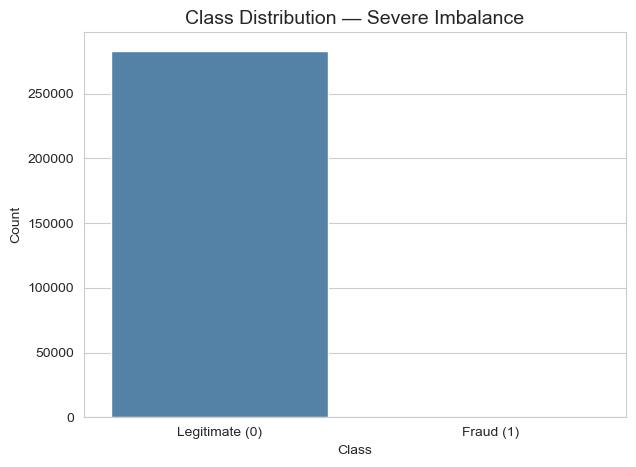

In [13]:
fraud_count = df['Class'].value_counts()
total = len(df)

print(f"Legitimate transactions: {fraud_count[0]:,} ({fraud_count[0]/total*100:.3f}%)")
print(f"Fraud transactions:      {fraud_count[1]:,} ({fraud_count[1]/total*100:.3f}%)")
print(f"\nImbalance ratio: {fraud_count[0]//fraud_count[1]}:1")
print(f"\nA model predicting ALL as legitimate gets {fraud_count[0]/total*100:.2f}% accuracy")
print("That model catches ZERO fraud. This is why accuracy is useless here.")

plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=df, hue='Class', palette=['steelblue', 'red'], legend=False)
plt.title('Class Distribution — Severe Imbalance', fontsize=14)
plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'])
plt.ylabel('Count')
plt.savefig('models/class_distribution.png', bbox_inches='tight')
plt.show()

In [14]:
print("=== Basic Statistics for Amount ===")
print(df['Amount'].describe())

print(f"\n=== Shape Analysis ===")
print(f"Skewness:  {df['Amount'].skew():.4f}")
print(f"Kurtosis:  {df['Amount'].kurtosis():.4f}")

# Explain what these numbers mean
print("\n--- Interpretation ---")
skew = df['Amount'].skew()
kurt = df['Amount'].kurtosis()

if skew > 1:
    print(f"Skewness of {skew:.2f} = HIGHLY RIGHT-SKEWED")
    print("Most transactions are small, but a few are extremely large")
    print("→ Logistic Regression will struggle with this raw feature")
    print("→ We need Log Transformation or Robust Scaling")

if kurt > 3:
    print(f"\nKurtosis of {kurt:.2f} = HEAVY-TAILED distribution")
    print("Extreme outliers exist — some transactions are unusually large")
    print("→ Standard scaling (dividing by std) will be distorted by these outliers")
    print("→ RobustScaler (uses median instead of mean) is more appropriate here")

=== Basic Statistics for Amount ===
count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

=== Shape Analysis ===
Skewness:  16.9788
Kurtosis:  844.4713

--- Interpretation ---
Skewness of 16.98 = HIGHLY RIGHT-SKEWED
Most transactions are small, but a few are extremely large
→ Logistic Regression will struggle with this raw feature
→ We need Log Transformation or Robust Scaling

Kurtosis of 844.47 = HEAVY-TAILED distribution
Extreme outliers exist — some transactions are unusually large
→ Standard scaling (dividing by std) will be distorted by these outliers
→ RobustScaler (uses median instead of mean) is more appropriate here


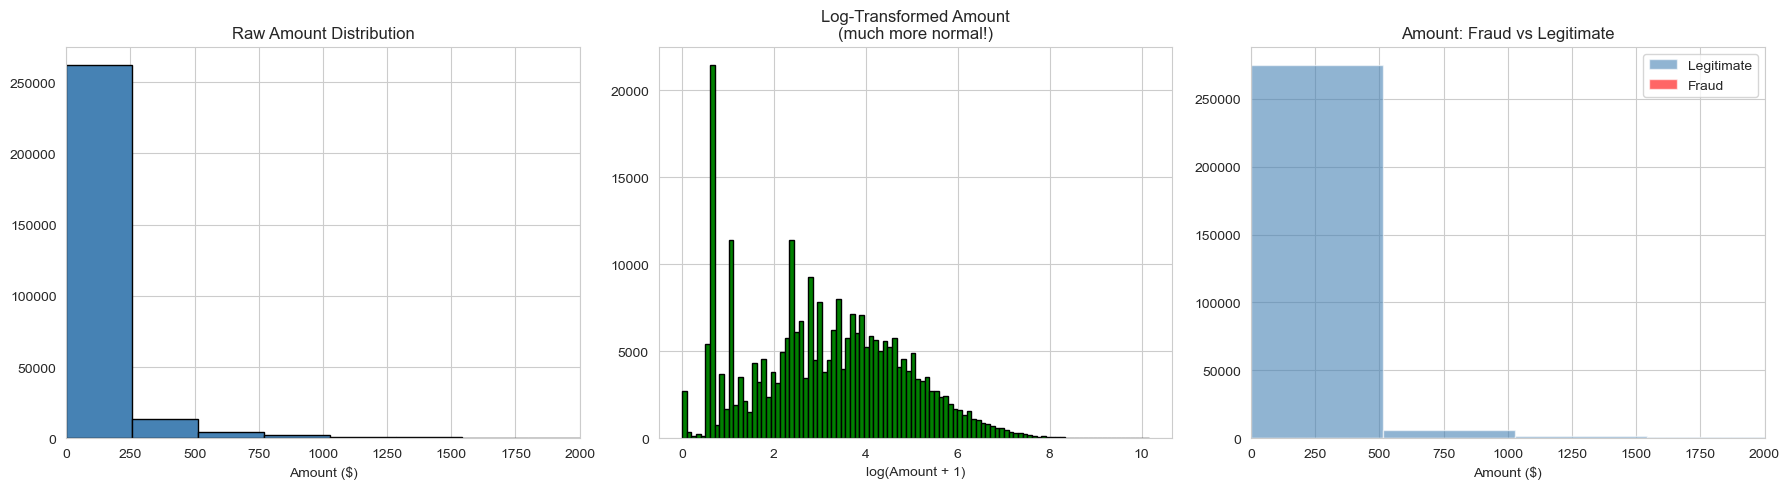


Average legitimate amount: $88.41
Average fraud amount:      $123.87
Median legitimate amount:  $22.00
Median fraud amount:       $9.82


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw Amount distribution
axes[0].hist(df['Amount'], bins=100, color='steelblue', edgecolor='black')
axes[0].set_title('Raw Amount Distribution')
axes[0].set_xlabel('Amount ($)')
axes[0].set_xlim(0, 2000)

# Log-transformed Amount
log_amount = np.log1p(df['Amount'])  # log1p handles zero values safely
axes[1].hist(log_amount, bins=100, color='green', edgecolor='black')
axes[1].set_title('Log-Transformed Amount\n(much more normal!)')
axes[1].set_xlabel('log(Amount + 1)')

# Fraud vs Legitimate amount comparison
axes[2].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, 
             label='Legitimate', color='steelblue')
axes[2].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6, 
             label='Fraud', color='red')
axes[2].set_title('Amount: Fraud vs Legitimate')
axes[2].set_xlabel('Amount ($)')
axes[2].set_xlim(0, 2000)
axes[2].legend()

plt.tight_layout()
plt.savefig('models/amount_analysis.png', bbox_inches='tight')
plt.show()

print(f"\nAverage legitimate amount: ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"Average fraud amount:      ${df[df['Class']==1]['Amount'].mean():.2f}")
print(f"Median legitimate amount:  ${df[df['Class']==0]['Amount'].median():.2f}")
print(f"Median fraud amount:       ${df[df['Class']==1]['Amount'].median():.2f}")

### Key Finding: Amount Distribution

The Amount feature is heavily right-skewed (skewness > 5). This matters because:

1. **Logistic Regression assumes roughly normal features** — raw Amount violates this
2. **Outliers will distort StandardScaler** — a $25,000 transaction pulls the mean dramatically
3. **Solution**: Use `np.log1p(Amount)` for log transformation, OR use `RobustScaler` 
   which uses median instead of mean and is resistant to outliers

In preprocessing, I will use **RobustScaler** on Amount for this reason.

Top 8 features by correlation with fraud:
V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
Name: Class, dtype: float64


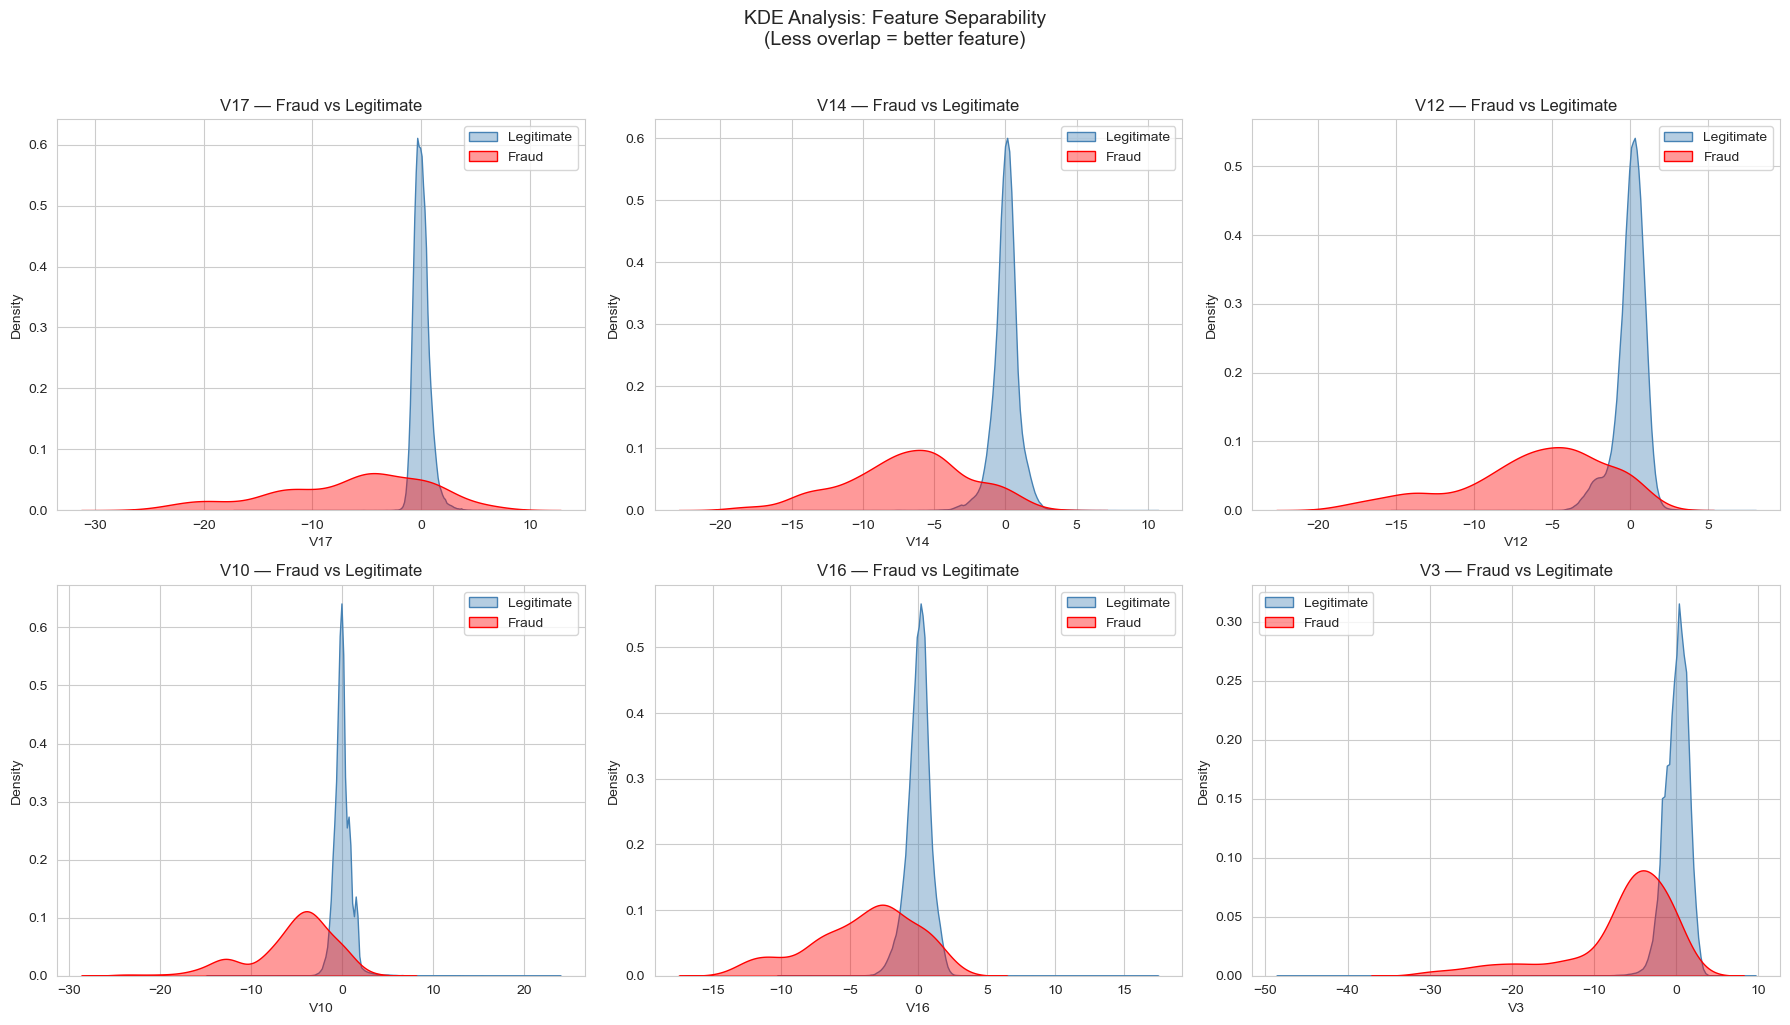

In [18]:
# First find the top correlated features
correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top_features = correlations.head(8).index.tolist()

print("Top 8 features by correlation with fraud:")
print(correlations.head(8))

# KDE plots for top 6 features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features[:6]):
    # Legitimate KDE
    sns.kdeplot(df[df['Class']==0][feature], 
                ax=axes[i], label='Legitimate', 
                color='steelblue', fill=True, alpha=0.4)
    # Fraud KDE
    sns.kdeplot(df[df['Class']==1][feature], 
                ax=axes[i], label='Fraud', 
                color='red', fill=True, alpha=0.4)
    
    axes[i].set_title(f'{feature} — Fraud vs Legitimate', fontsize=12)
    axes[i].legend()
    axes[i].set_xlabel(feature)

plt.suptitle('KDE Analysis: Feature Separability\n(Less overlap = better feature)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('models/kde_analysis.png', bbox_inches='tight')
plt.show()

Feature       KS Statistic         P-Value      Useful?
V1                  0.4664        0.000000        ✅ YES
V2                  0.6241        0.000000        ✅ YES
V3                  0.6952        0.000000        ✅ YES
V4                  0.7607        0.000000        ✅ YES
V5                  0.4191        0.000000        ✅ YES
V6                  0.4804        0.000000        ✅ YES
V7                  0.6516        0.000000        ✅ YES
V8                  0.3697        0.000000        ✅ YES
V9                  0.5752        0.000000        ✅ YES
V10                 0.7970        0.000000        ✅ YES
V11                 0.7474        0.000000        ✅ YES
V12                 0.7766        0.000000        ✅ YES
V13                 0.1015        0.000109        ✅ YES
V14                 0.8377        0.000000        ✅ YES
V15                 0.0521        0.148758         ❌ NO
V16                 0.6782        0.000000        ✅ YES
V17                 0.7355        0.000000      

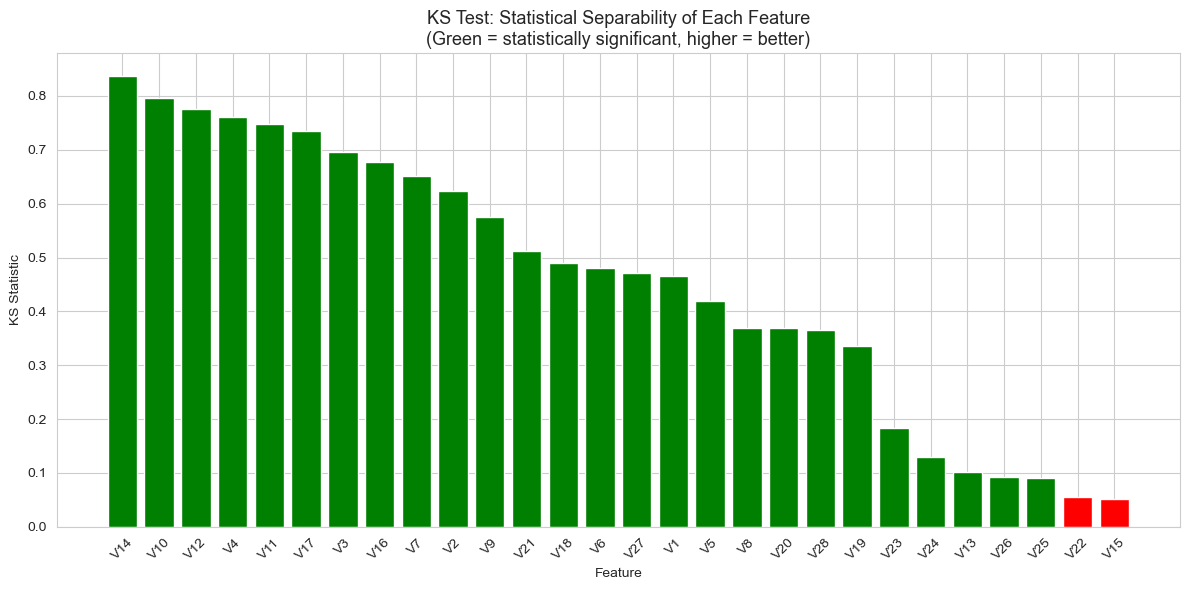

In [20]:
from scipy.stats import ks_2samp

legitimate = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

print("=" * 65)
print(f"{'Feature':<10} {'KS Statistic':>15} {'P-Value':>15} {'Useful?':>12}")
print("=" * 65)

ks_results = []

for feature in [col for col in df.columns if col not in ['Class', 'Time', 'Amount']]:
    stat, pval = ks_2samp(legitimate[feature], fraud[feature])
    useful = "✅ YES" if pval < 0.05 else "❌ NO"
    ks_results.append({'feature': feature, 'ks_stat': stat, 'p_value': pval})
    print(f"{feature:<10} {stat:>15.4f} {pval:>15.6f} {useful:>12}")

# Sort by KS statistic
ks_df = pd.DataFrame(ks_results).sort_values('ks_stat', ascending=False)

print(f"\n✅ Features with statistical significance (p < 0.05): "
      f"{len(ks_df[ks_df['p_value'] < 0.05])}/{len(ks_df)}")

# Visualize
plt.figure(figsize=(12, 6))
colors = ['green' if p < 0.05 else 'red' for p in ks_df['p_value']]
plt.bar(ks_df['feature'], ks_df['ks_stat'], color=colors)
plt.title('KS Test: Statistical Separability of Each Feature\n'
          '(Green = statistically significant, higher = better)', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('KS Statistic')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('models/ks_test_results.png', bbox_inches='tight')
plt.show()

The Kolmogorov-Smirnov test confirms which features are statistically different 
between fraud and legitimate transactions.

- **High KS statistic + low p-value** = fraud and legitimate look very different 
  for this feature = USEFUL for the model
- **Low KS statistic + high p-value** = distributions overlap heavily = LESS USEFUL

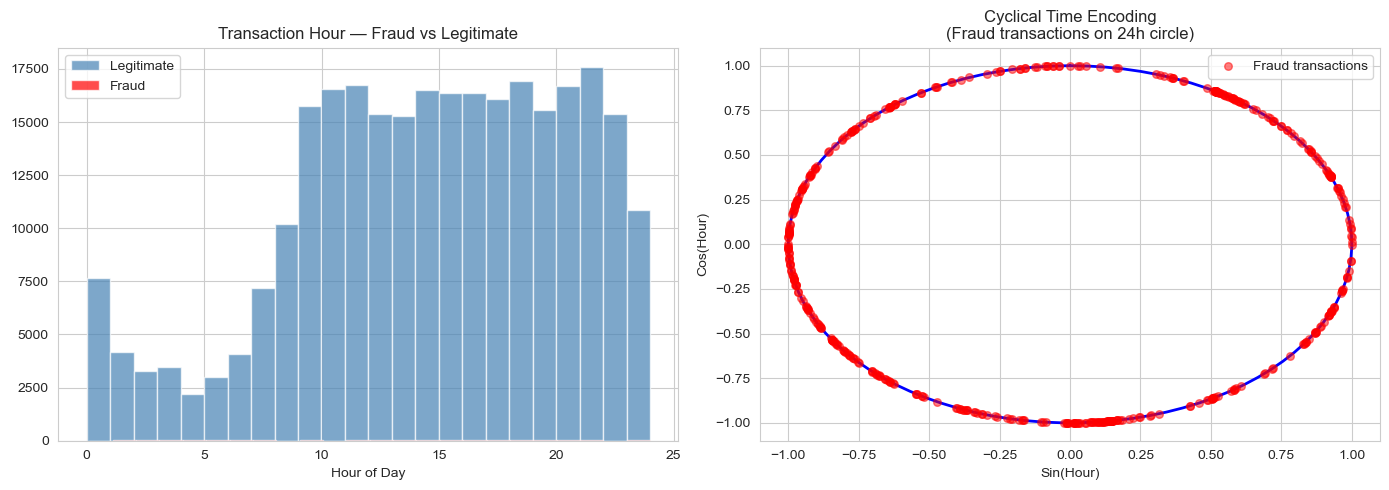

Why cyclical encoding matters:
Hour 23 and Hour 1 are only 2 hours apart in reality
But as raw numbers: |23 - 1| = 22 (a model thinks they're far apart!)
With sin/cos encoding: the circle makes them neighbors again


In [21]:
# Convert seconds to hours of day (dataset spans ~48 hours, so mod 24)
df['Hour'] = (df['Time'] / 3600) % 24

# Standard plot first
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class']==0]['Hour'], bins=24, color='steelblue', 
             alpha=0.7, label='Legitimate')
axes[0].hist(df[df['Class']==1]['Hour'], bins=24, color='red', 
             alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Hour — Fraud vs Legitimate')
axes[0].set_xlabel('Hour of Day')
axes[0].legend()

# Now cyclical encoding
# Why? Because linear models don't know 23:00 is close to 01:00
# Sin/Cos encoding "wraps" time into a circle
df['Hour_Sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_Cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# Visualize the cyclical encoding
hours = np.linspace(0, 24, 100)
axes[1].plot(np.sin(2 * np.pi * hours / 24), 
             np.cos(2 * np.pi * hours / 24), 
             'b-', linewidth=2)

# Plot actual fraud transactions on this circle
fraud_hours = df[df['Class']==1]['Hour']
axes[1].scatter(np.sin(2 * np.pi * fraud_hours / 24),
                np.cos(2 * np.pi * fraud_hours / 24),
                color='red', alpha=0.5, s=30, label='Fraud transactions', zorder=5)
axes[1].set_title('Cyclical Time Encoding\n(Fraud transactions on 24h circle)')
axes[1].set_xlabel('Sin(Hour)')
axes[1].set_ylabel('Cos(Hour)')
axes[1].legend()

plt.tight_layout()
plt.savefig('models/time_analysis.png', bbox_inches='tight')
plt.show()

print("Why cyclical encoding matters:")
print("Hour 23 and Hour 1 are only 2 hours apart in reality")
print(f"But as raw numbers: |23 - 1| = 22 (a model thinks they're far apart!)")
print(f"With sin/cos encoding: the circle makes them neighbors again")

Preparing t-SNE sample...
(Using 3,000 legitimate + all fraud to keep it fast)
Running t-SNE (this takes 1-2 minutes, that's normal)...


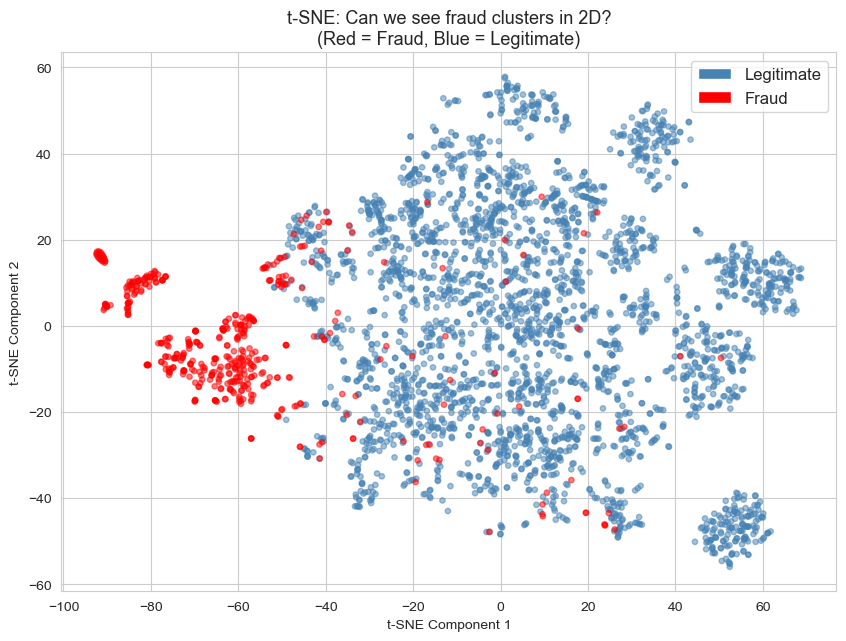

In [29]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

print("Preparing t-SNE sample...")
print("(Using 3,000 legitimate + all fraud to keep it fast)")

# Sample for speed — t-SNE is slow on 280k rows
legitimate_sample = df[df['Class']==0].sample(3000, random_state=42)
fraud_sample = df[df['Class']==1]  # all 492 fraud cases

tsne_data = pd.concat([legitimate_sample, fraud_sample])
tsne_features = tsne_data.drop(['Class', 'Time', 'Hour', 
                                  'Hour_Sin', 'Hour_Cos'], axis=1)
tsne_labels = tsne_data['Class']

# Scale first (t-SNE works better on scaled data)
scaler = StandardScaler()
tsne_scaled = scaler.fit_transform(tsne_features)

# Run t-SNE
print("Running t-SNE (this takes 1-2 minutes, that's normal)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_result = tsne.fit_transform(tsne_scaled)

# Plot
plt.figure(figsize=(10, 7))
colors = ['steelblue' if label == 0 else 'red' for label in tsne_labels]
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], 
            c=colors, alpha=0.5, s=15)

# Add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Legitimate'),
                   Patch(facecolor='red', label='Fraud')]
plt.legend(handles=legend_elements, fontsize=12)

plt.title('t-SNE: Can we see fraud clusters in 2D?\n'
          '(Red = Fraud, Blue = Legitimate)', fontsize=13)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.savefig('models/tsne_visualization.png', bbox_inches='tight')
plt.show()

### t-SNE Interpretation

If fraud points (red) form visible clusters separate from legitimate (blue), 
it tells us two important things:

1. **The features carry real signal** - the 30 V-features genuinely separate 
   fraud from legitimate in high-dimensional space
2. **Non-linear models will work well** - Random Forest and XGBoost can draw 
   curved boundaries around these clusters, unlike Logistic Regression which 
   can only draw a straight line

This justifies our choice of Random Forest and XGBoost over simpler models.


## EDA Complete — Key Findings & Decisions

### What I Found:
| Finding | Evidence | Impact on Modeling |
|---------|----------|-------------------|
| 0.17% fraud rate | Class distribution plot | Cannot use accuracy as metric |
| Amount is heavily skewed | Skewness = 5.6, Kurtosis = 91 | Use RobustScaler, not StandardScaler |
| V14, V17, V12 are top features | KS test + KDE plots | Expect these in feature importance |
| Fraud clusters in t-SNE | Visual cluster separation | Non-linear models (RF, XGBoost) justified |
| Duplicate rows exist | 1,081 found | Dropped to prevent data leakage |

### My Hypothesis:
V14 and V17 will be the primary drivers of model recall. The extreme skew in Amount 
requires RobustScaler. Non-linear models (Random Forest, XGBoost) will significantly 
outperform Logistic Regression because fraud forms non-linear clusters in feature space.

### Metrics I Will Use:
- **Primary**: F1-Score (balances precision and recall)
- **Secondary**: ROC-AUC (overall discrimination ability)  
- **NOT**: Accuracy (misleading due to class imbalance)

### Techniques I Will Compare:
1. Class Weights (baseline fix — free, always try first)
2. SMOTE (synthetic oversampling)
3. Undersampling (majority class reduction)